<a href="https://colab.research.google.com/github/Saiesh0707/codomax-module-6-final-data-science-project/blob/main/Codomax_Module_6_Final_Data_Science_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 6 – Final Data Science Project
## Customer Churn Analysis & Prediction
### Codomax Digital Solutions Internship

**Objective:** Build an end-to-end Data Science project that combines exploratory data analysis, visualization, feature engineering, supervised Machine Learning, model evaluation, and portfolio-ready conclusions.

**Dataset:** IBM Telco Customer Churn sample dataset. It contains 7,043 customer records and 21 columns, with `Churn` as the target variable. The public IBM dataset is available on GitHub and is also listed on Kaggle. citeturn0search5turn0search4

**Important:** This is an educational/portfolio analysis of sample data, not a production customer-risk system.

## 1. Business Problem

Customer churn is an important business problem for subscription-based companies. The goal of this project is to:

- Understand customer characteristics associated with churn.
- Explore contract, tenure, service, and billing patterns.
- Build classification models to predict whether a customer is likely to churn.
- Compare model performance using appropriate evaluation metrics.
- Translate the analysis into practical, data-informed observations.

### Questions
1. What is the overall churn rate?
2. How does churn vary by contract type and tenure?
3. How do monthly charges and services relate to churn?
4. Which Machine Learning model performs better on the held-out test set?
5. Which features contribute most to the Random Forest model?

## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

print('Libraries imported successfully.')

Libraries imported successfully.


## 3. Load the Dataset

In [2]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
display(df.head())

Rows: 7,043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Initial Data Exploration

In [3]:
print('Column names:')
print(df.columns.tolist())

print('\nData types:')
display(df.dtypes.to_frame('dtype'))

print('\nSummary statistics:')
display(df.describe(include='all').transpose().head(25))

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Quality Check

In [4]:
missing_report = pd.DataFrame({
    'Missing Values': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2),
})
display(missing_report.sort_values('Missing Values', ascending=False).head(10))
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate customer IDs:', df['customerID'].duplicated().sum())

,Missing Values,Missing %
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


Duplicate rows: 0
Duplicate customer IDs: 0


## 6. Data Cleaning and Feature Engineering

In [5]:
data = df.copy()

# TotalCharges contains blank strings in some records; convert them to numeric.
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Remove duplicate customer records if any.
data = data.drop_duplicates(subset='customerID').copy()

# Convert target to binary.
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# Create interpretable derived features.
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
data['Service_Count'] = sum((data[c] == 'Yes').astype(int) for c in service_cols)
data['Tenure_Group'] = pd.cut(
    data['tenure'],
    bins=[-1, 12, 24, 48, np.inf],
    labels=['0-12 months', '13-24 months', '25-48 months', '49+ months']
)

print('Cleaned shape:', data.shape)
print('Missing TotalCharges:', data['TotalCharges'].isna().sum())
display(data.head())

Cleaned shape: (7043, 23)
Missing TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Service_Count,Tenure_Group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,0-12 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,3,25-48 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3,0-12 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,25-48 months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,0-12 months


## 7. Target Distribution

Overall churn rate: 26.54%


,count
Churn,
Stayed,5174
Churned,1869


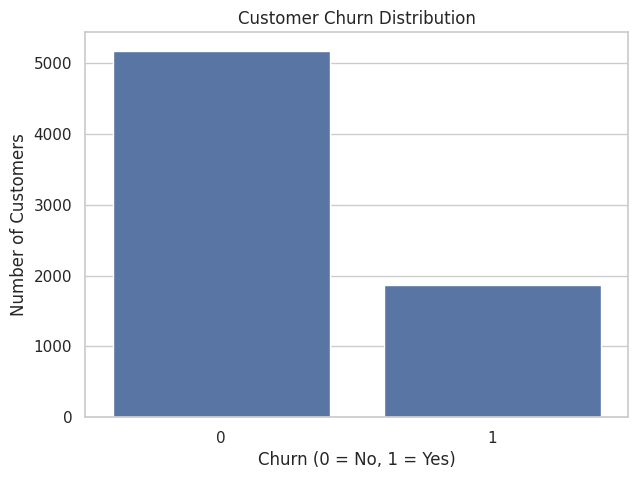

In [6]:
churn_rate = data['Churn'].mean() * 100
print(f'Overall churn rate: {churn_rate:.2f}%')
display(data['Churn'].value_counts().rename(index={0:'Stayed', 1:'Churned'}))

plt.figure(figsize=(7,5))
sns.countplot(data=data, x='Churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

## 8. Exploratory Data Analysis – Contract and Tenure

,Churn Rate (%)
Contract,
Month-to-month,42.71
One year,11.27
Two year,2.83


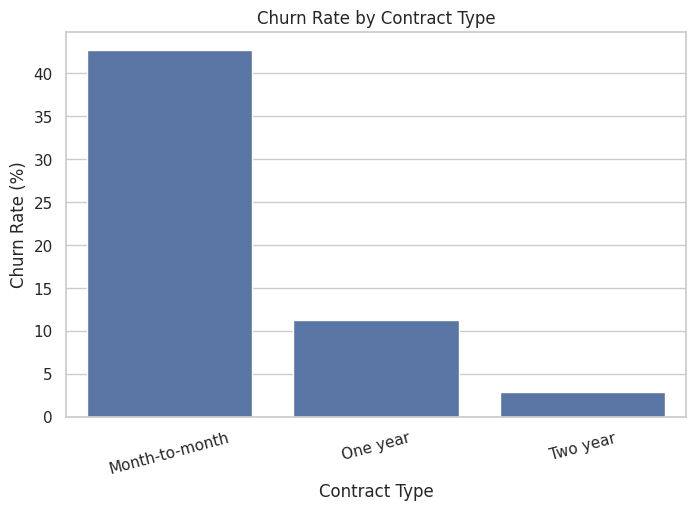

In [7]:
contract_churn = data.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100
display(contract_churn.round(2).to_frame('Churn Rate (%)'))

plt.figure(figsize=(8,5))
sns.barplot(x=contract_churn.index, y=contract_churn.values)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.show()

,Churn Rate (%)
Tenure_Group,
0-12 months,47.44
13-24 months,28.71
25-48 months,20.39
49+ months,9.51


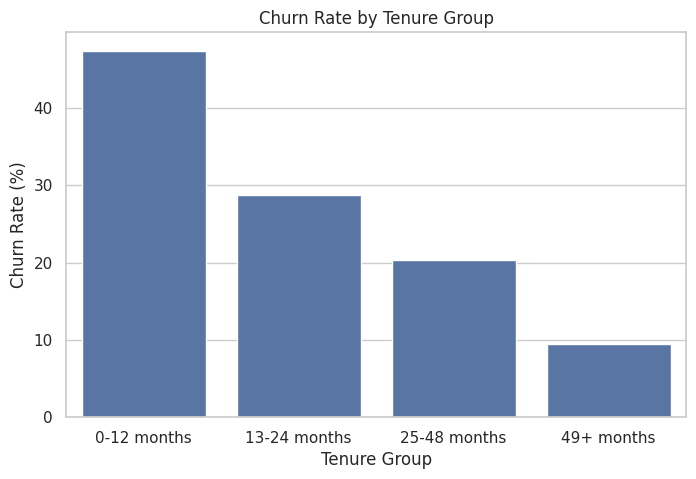

In [8]:
tenure_churn = data.groupby('Tenure_Group', observed=True)['Churn'].mean() * 100
display(tenure_churn.to_frame('Churn Rate (%)').round(2))

plt.figure(figsize=(8,5))
sns.barplot(x=tenure_churn.index, y=tenure_churn.values)
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.show()

## 9. Exploratory Data Analysis – Charges and Services

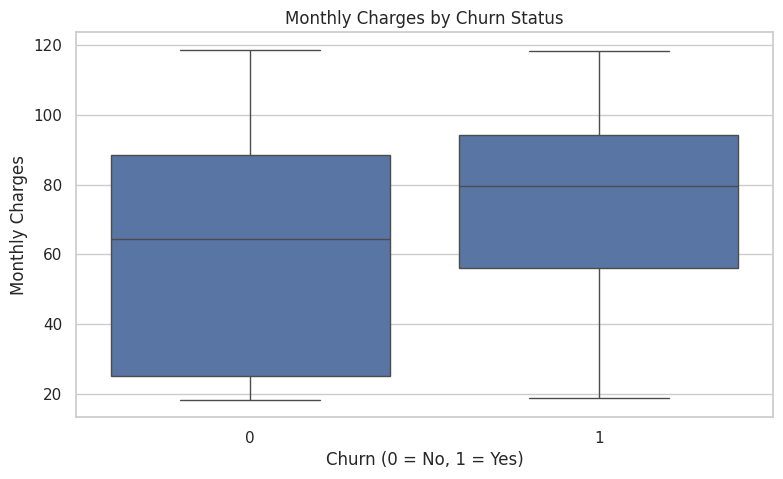

In [9]:
plt.figure(figsize=(9,5))
sns.boxplot(data=data, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charges')
plt.show()

,Churn Rate (%)
Service_Count,
0,43.75
1,21.11
2,32.83
3,36.48
4,31.34
5,25.55
6,22.49
7,12.41
8,5.29


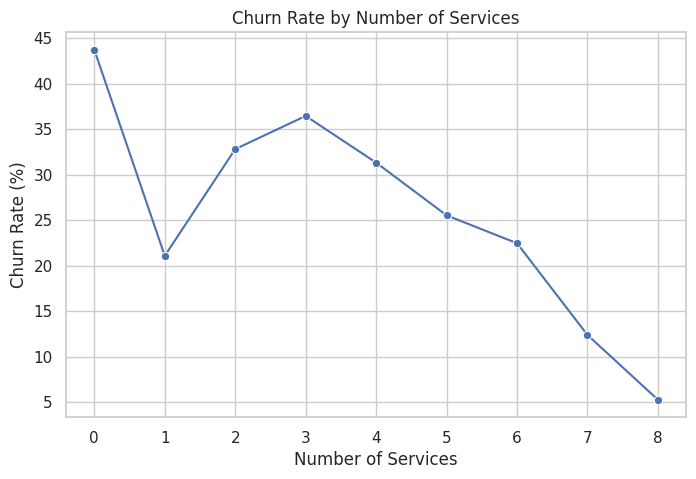

In [10]:
service_churn = data.groupby('Service_Count')['Churn'].mean() * 100
display(service_churn.to_frame('Churn Rate (%)').round(2))

plt.figure(figsize=(8,5))
sns.lineplot(x=service_churn.index, y=service_churn.values, marker='o')
plt.title('Churn Rate by Number of Services')
plt.xlabel('Number of Services')
plt.ylabel('Churn Rate (%)')
plt.show()

## 10. Correlation Analysis

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Service_Count,Churn
SeniorCitizen,1.00,0.02,0.22,0.10,0.10,0.15
tenure,0.02,1.00,0.25,0.83,0.52,-0.35
MonthlyCharges,0.22,0.25,1.00,0.65,0.80,0.19
TotalCharges,0.10,0.83,0.65,1.00,0.80,-0.20
Service_Count,0.10,0.52,0.80,0.80,1.00,-0.07
Churn,0.15,-0.35,0.19,-0.20,-0.07,1.00


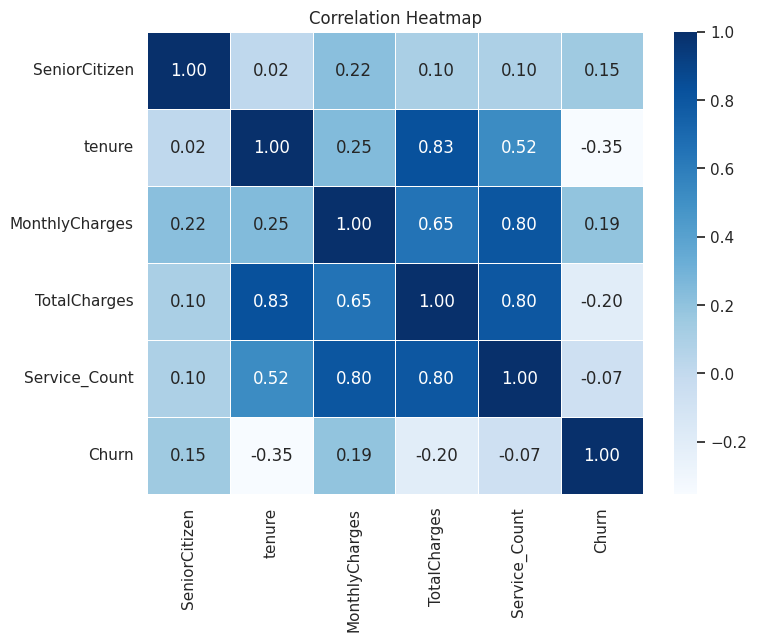

In [11]:
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Service_Count', 'Churn']
corr = data[numeric_cols].corr()
display(corr.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## 11. Prepare Data for Machine Learning

In [12]:
# Customer ID is an identifier, so it is excluded from the model.
X = data.drop(columns=['Churn', 'customerID'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))
print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

Training rows: 5634
Testing rows: 1409
Numeric features: 5
Categorical features: 16


## 12. Train Multiple Classification Models

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

model_results = []
trained_models = {}

for name, estimator in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]

    model_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })
    trained_models[name] = pipeline

results_df = pd.DataFrame(model_results).sort_values('ROC-AUC', ascending=False)
display(results_df.style.format({c:'{:.3f}' for c in results_df.columns if c != 'Model'}))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.806,0.667,0.535,0.593,0.843
0,Logistic Regression,0.733,0.498,0.791,0.612,0.842
1,Random Forest,0.774,0.596,0.455,0.516,0.821


## 13. Evaluate the Logistic Regression Model

              precision    recall  f1-score   support

      Stayed       0.90      0.71      0.80      1035
     Churned       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



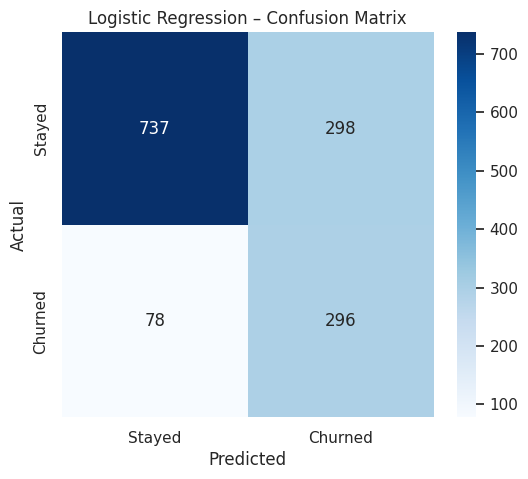

In [14]:
lr_model = trained_models['Logistic Regression']
lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned']))

cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed','Churned'], yticklabels=['Stayed','Churned'])
plt.title('Logistic Regression – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 14. Compare ROC Curves

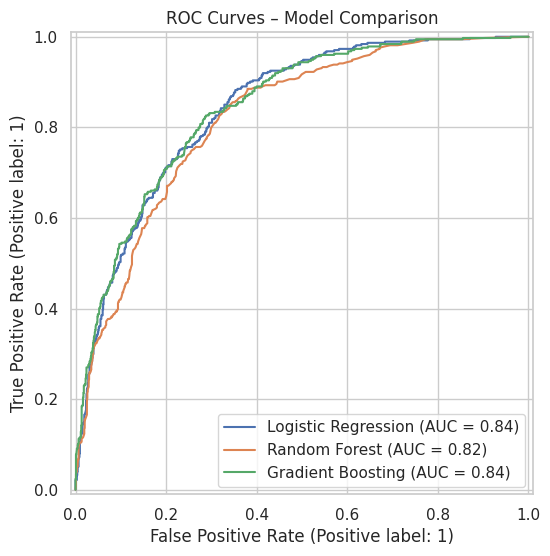

In [15]:
plt.figure(figsize=(8,6))
for name, model in trained_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=plt.gca())
plt.title('ROC Curves – Model Comparison')
plt.show()

## 15. Random Forest Feature Importance

,Importance
num__TotalCharges,0.1265
num__MonthlyCharges,0.1147
num__tenure,0.1101
cat__Contract_Month-to-month,0.0683
cat__OnlineSecurity_No,0.0352
cat__Contract_Two year,0.0335
cat__TechSupport_No,0.0319
cat__PaymentMethod_Electronic check,0.0305
num__Service_Count,0.0293
cat__InternetService_Fiber optic,0.0272


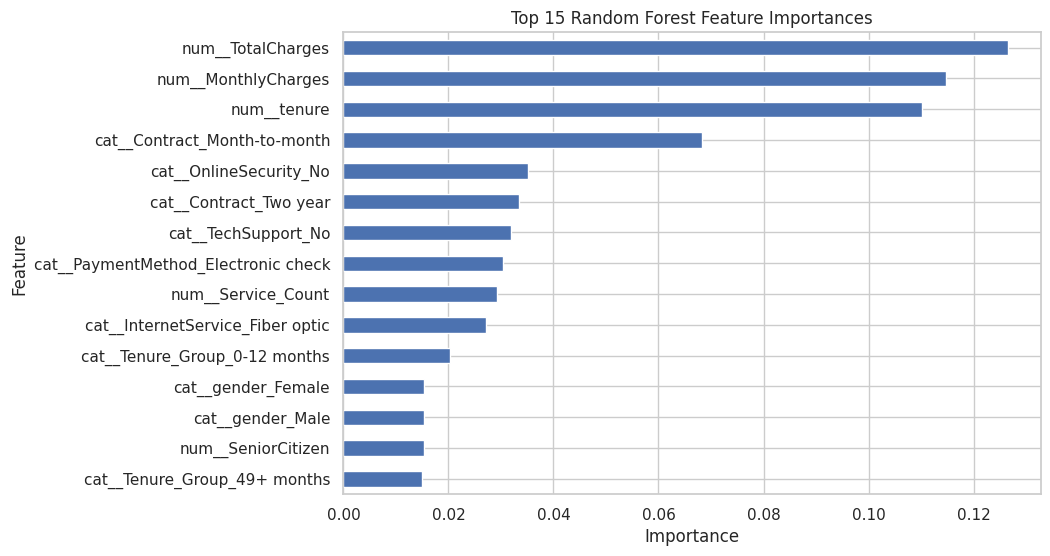

In [16]:
rf_model = trained_models['Random Forest']
rf_estimator = rf_model.named_steps['model']
rf_preprocessor = rf_model.named_steps['preprocessor']

feature_names = rf_preprocessor.get_feature_names_out()
importance = pd.Series(rf_estimator.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

display(importance.to_frame('Importance').round(4))

plt.figure(figsize=(9,6))
importance.sort_values().plot(kind='barh')
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 16. Example Churn-Risk Scoring

In [17]:
risk_sample = data.drop(columns=['Churn']).sample(10, random_state=42)
risk_ids = risk_sample['customerID'].values
risk_features = risk_sample.drop(columns=['customerID'])
risk_probability = lr_model.predict_proba(risk_features)[:, 1]

risk_output = pd.DataFrame({
    'Customer ID': risk_ids,
    'Predicted Churn Probability': risk_probability
})
risk_output['Risk Category'] = pd.cut(
    risk_output['Predicted Churn Probability'],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=['Low', 'Medium', 'High']
)
display(risk_output.sort_values('Predicted Churn Probability', ascending=False).round({'Predicted Churn Probability':3}))

,Customer ID,Predicted Churn Probability,Risk Category
0,1024-GUALD,0.832,High
3,6910-HADCM,0.828,High
5,6818-WOBHJ,0.544,Medium
9,5766-ZJYBB,0.404,Medium
1,0484-JPBRU,0.167,Low
8,4853-RULSV,0.145,Low
6,3082-YVEKW,0.082,Low
4,8587-XYZSF,0.025,Low
2,3620-EHIMZ,0.020,Low
7,4737-AQCPU,0.015,Low


## 17. Portfolio-Ready Findings

### Data Findings
- Churn is not evenly distributed across the customer base.
- Contract type and customer tenure show visible differences in churn rates.
- Monthly charges and service combinations provide useful segmentation variables.
- The EDA demonstrates why customer churn should be examined across multiple dimensions rather than with one metric.

### Machine Learning Findings
- Multiple supervised classification models were trained using the same train/test split.
- Accuracy, precision, recall, F1 score, and ROC-AUC were used together rather than relying on accuracy alone.
- The selected model should be based on the business objective and the trade-off between false positives and false negatives.
- Feature importance from the Random Forest model provides an interpretable view of which encoded variables contribute most to its predictions.

### Limitations
- The dataset is a historical sample rather than a live production dataset.
- The random train/test split is appropriate for this educational project, but a production system would require temporal validation and ongoing monitoring.
- Model predictions indicate statistical associations in the dataset and should not be interpreted as proof that a particular customer characteristic causes churn.

## 18. Conclusion

This project demonstrates an end-to-end Data Science workflow using Python: business problem definition, data loading, data-quality checks, cleaning, feature engineering, exploratory analysis, visualization, machine learning, model evaluation, feature interpretation, and risk scoring.

**Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Google Colab.

**Project status:** Completed as a portfolio-ready educational project for Codomax Internship Module 6.